<a href="https://colab.research.google.com/github/Stivencaballero0710/simulador-colisiones/blob/main/Taller1_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 1: Autómatas finitos

**Autómatas y Lenguajes Formales**

**Profesor: Luis Carlos Guayacán**

**Escuela de Ingeniería de Sistemas e Informática**

_Febrero de 2026_

<ul>
<li>Suba el archivo correspondiente a la solución del taller al Moodle.<br>Plazo de entrega: viernes <b style="color:#F00;">06 de marzo / 2025</b> - 11:59 p.m.</li>
<li>Se recomienda utilizar la herramienta "Finite State Machine Designer" ( http://madebyevan.com/fsm/ ) para diseñar los diagramas de estados.</li>
</ul>

<div style="height:100px;"></div>

<span style="font-size:20px;font-weight:bold;"><span style="background-color:#F00;color:#FFF;padding:10px;">Obligatorio</span> Ejecute estas celdas para iniciar la actividad</span>

In [ ]:
!mkdir files
!pip install automata-lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 2.1 MB/s eta 0:00:00


In [ ]:
from IPython.display import Image, display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<div style="height:100px;"></div>

## Autómatas finitos deterministas (AFD)

**1)** Construya un autómata finito determinista (DFA) sobre el alfabeto $\Sigma = {\{0, 1\}}$ que acepte todas las cadenas que cumplen simultáneamente:
- El número de símbolos 1 en la cadena es par.
- La cadena termina en 1.

**NOTA** Dibuje el diagrama de transiciones e implemente el autómata con automata-lib.

**Diagrama de transiciones:**

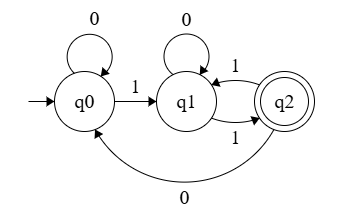

In [ ]:
display(Image('drive/MyDrive/files/ejercicio1.png'))

**Implementación del autómata con automata-lib**:

In [ ]:
def punto1():
    from automata.fa.dfa import DFA
    d = DFA(
        states={'q0','q1','q2'},
        input_symbols={'0','1'},
        transitions={
          'q0':{'0':'q0','1':'q1'},
          'q1':{'0':'q1','1':'q2'},
          'q2':{'0':'q0','1':'q1'},
        },
        initial_state='q0',
        final_states={'q2'},
        allow_partial=True
    )
    return d




#### Evalue su respuesta antes de subirla:


In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_1():
    d = punto1()
    valid_words = ['11','101','1111','011','00011','101011','110011','010111','111111']

    invalid_words = ['','0','1','01','001','10101','1101','10','1110','000','1000','1010','11100','010','1100']
    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_1():
    print('MUY BIEN! El diseño es correcto')
else:
    print('MAL! El diseño es incorrecto. Sigue intentando')



MUY BIEN! El diseño es correcto


<div style="height:100px;"></div>

# Autómatas finitos no deterministas (AFN)

**2**) Diseñe un autómata que acepte todas las cadenas sobre el alfabeto $\Sigma=\{m,n,x,y\}$ , tales que:<br><br>
$$L = \{\enspace x \ (mn)^{*} \ m \ (xy)^{*} \ x^{+} \ n \enspace \}$$

**NOTA** Dibuje LOS diagramas de transiciones e implemente el autómata DETERMINISTA con automata-lib.

**Diagrama de transiciones (NFA):**

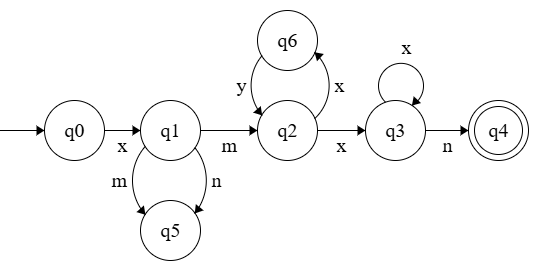

In [ ]:
display(Image('drive/MyDrive/files/Ejercicio2.png'))

**Diagrama de transiciones (DFA):**

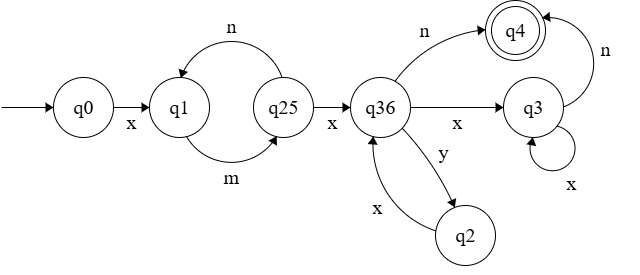

In [ ]:
display(Image('drive/MyDrive/files/Ejercicio2DFA.png'))

**Implementación del autómata DETERMINISTA con automata-lib**:

In [ ]:
def punto2():
    from automata.fa.dfa import DFA

    d = DFA(
        states ={'q0','q1','q25','q36','q2','q3','q4'},
        input_symbols={'x','m','y','n'},
        transitions={
            'q0':{'x':'q1'},
            'q1':{'m':'q25'},
            'q25':{'x':'q36','n':'q1'},
            'q36':{'x':'q3','y':'q2','n':'q4'},
            'q2':{'x':'q36'},
            'q3':{'x':'q3','n':'q4'},
            'q4':{}
        },
        initial_state='q0',
        final_states={'q4'},
        allow_partial = True
    )
    return d


#### Evalue su respuesta antes de subirla:


In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_2():
    d = punto2()
    valid_words = ['xmnmxyxxn',
                   'xmnmnmxyxyxn',
                   'xmnmnmxn',
                   'xmxxxxxn',
                   'xmxyxxn']
    invalid_words = ['xxmnmxyxn',
                     'xymnmxyxxxn',
                     'xnmnnnxn',
                     'xmnmxyn',
                     'xnxyxyn']

    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_2():
  print('MUY BIEN! El diseño es correcto')
else:
  print('MAL! El diseño es incorrecto. Sigue intentando')

MUY BIEN! El diseño es correcto


<div style="height:100px;"></div>

**3)** Diseñe un autómata finito NO determinista con transiciones epsilon para el lenguaje:

$$L = \{ \enspace a^+bb(cd)^*e(de)^+a \enspace ∪ \enspace a(ba)^∗c(ae)^+d \enspace \} $$

Dado el alfabeto: $\Sigma = \{a, b, c, d, e\}$

**NOTA** Dibuje el diagrama de transiciones e implemente el autómata NO determinista y DETERMINISTA con automata-lib.

**Diagrama de transiciones NO determinista:**

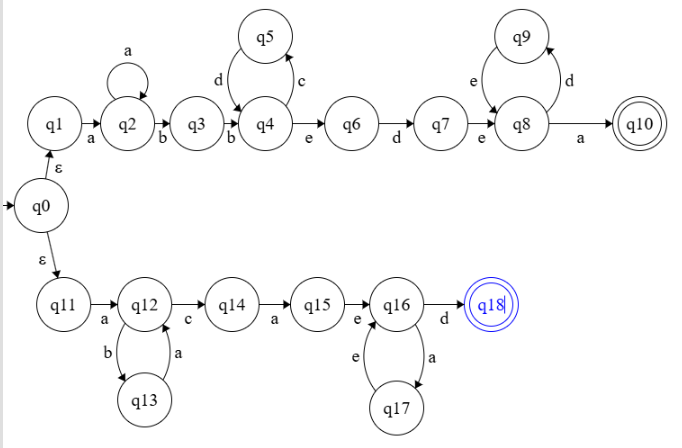

In [ ]:
display(Image('drive/MyDrive/files/Ejercicio3.png'))

**a)  Implementación del autómata NO determinista con automata-lib**:

In [ ]:
def punto3_a():
    from automata.fa.nfa import NFA
    d = NFA(
        states={'q0','q1','q2','q3','q4','q5','q6','q7','q8','q9','q10', 'q11','q12','q13','q14','q15','q16','q17','q18'},
        input_symbols={'a','b','c','d','e'},
        transitions={
            'q0':{'':{'q1','q11'}},
            'q1':{'a':{'q2'}},
            'q2':{'a':{'q2'},'b':{'q3'}},
            'q3':{'b':{'q4'}},
            'q4':{'c':{'q5'},'e':{'q6'}},
            'q5':{'d':{'q4'}},
            'q6':{'d':{'q7'}},
            'q7':{'e':{'q8'}},
            'q8':{'d':{'q9'},'a':{'q10'}},
            'q9':{'e':{'q8'}},
            'q10':{},
            'q11':{'a':{'q12'}},
            'q12':{'b':{'q13'},'c':{'q14'}},
            'q13':{'a':{'q12'}},
            'q14':{'a':{'q15'}},
            'q15':{'e':{'q16'}},
            'q16':{'a':{'q17'},'d':{'q18'}},
            'q17':{'e':{'q16'}},
            'q18':{},


            },
        initial_state='q0',
        final_states={'q10','q18'},
    )
    return d




#### Evalue su respuesta antes de subirla:

In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_3_a():
    d = punto3_a()
    valid_words = ['aaaabbcdededea','aaaabbededea','aaabbcdcdcdededea',
                   'aaabbcdededea','aaabbedededea','aabbcdedededea',
                   'abababacaeaed','ababacaeaeaed','ababacaeaed',
                   'ababacaed','abacaeaeaed','abacaeaed',
                   'abacaed','abbcdcdcdedededea','abbcdcdededea',
                   'abbcdedea','abbcdededea','abbedededea']

    invalid_words = ['abbcdcdedede','aaaabbedede','abbcdede', 'bbcdede',
                     'abbedededeaa','aabbcdedededeaa','abacaeae',
                     'abbcdedeaa','abacaeaea','abbcdcdcdededede',
                     'ababacae','abacaeaeae','ababacaeae',
                     'aaabbcdededeaa','ababacaeaea','abbcdcdededeaa',
                     'aaabbcdcdcdededeaa','aaaabbededeaa','aaabbcdedede']

    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_3_a():
    print('MUY BIEN! El diseño es correcto')
else:
    print('MAL! El diseño es incorrecto. Sigue intentando')


MUY BIEN! El diseño es correcto


<div style="height:100px;"></div>

**b) Implementación del autómata DETERMINISTA con automata-lib**:

In [ ]:
def punto3_b():
    from automata.fa.dfa import DFA

    d = DFA(
        states ={'q0111','q212','q2','q313','q14','q3','q12','q4','q15','q13','q5','q6','q16','q7','q17','q18','q8','q10','q9'},
        input_symbols ={'a','b','c','d','e'},
        transitions ={
            'q0111':{'a':'q212'},
            'q212':{'a':'q2','b':'q313','c':'q14'},
            'q2':{'a':'q2','b':'q3'},
            'q313':{'a':'q12','b':'q4'},
            'q14':{'a':'q15'},
            'q3':{'b':'q4'},
            'q12':{'b':'q13','c':'q14'},
            'q4':{'c':'q5','e':'q6'},
            'q15':{'e':'q16'},
            'q13':{'a':'q12'},
            'q5':{'d':'q4'},
            'q6':{'d':'q7'},
            'q16':{'a':'q17','d':'q18'},
            'q7':{'e':'q8'},
            'q17':{'e':'q16'},
            'q18':{},
            'q8':{'a':'q10','d':'q9'},
            'q10':{},
            'q9':{'e':'q8'},
        },
        initial_state ='q0111',
        final_states ={'q18','q10'},
        allow_partial = True
    )
    return d


In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_3_b():
    d = punto3_b()
    valid_words = ['aaaabbcdededea','aaaabbededea','aaabbcdcdcdededea',
                   'aaabbcdededea','aaabbedededea','aabbcdedededea',
                   'abababacaeaed','ababacaeaeaed','ababacaeaed',
                   'ababacaed','abacaeaeaed','abacaeaed',
                   'abacaed','abbcdcdcdedededea','abbcdcdededea',
                   'abbcdedea','abbcdededea','abbedededea']

    invalid_words = ['abbcdcdedede','aaaabbedede','abbcdede',
                     'abbedededeaa','aabbcdedededeaa','abacaeae',
                     'abbcdedeaa','abacaeaea','abbcdcdcdededede',
                     'ababacae','abacaeaeae','ababacaeae',
                     'aaabbcdededeaa','ababacaeaea','abbcdcdededeaa',
                     'aaabbcdcdcdededeaa','aaaabbededeaa','aaabbcdedede']

    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_3_b():
    print('MUY BIEN! El diseño es correcto')
else:
    print('MAL! El diseño es incorrecto. Sigue intentando')

MUY BIEN! El diseño es correcto


<br><br>

**4)** Diseñe un NFA sobre el alfabeto $\Sigma = \{8,3,5\}$ para el lenguaje:<br><br>
$$L = \{\enspace x338 \enspace \lor \enspace x35 \enspace \lor \enspace x383: \enspace x \in \{35\}^{*} \enspace \}$$

**NOTA** Dibuje el diagrama de transiciones e implemente el autómata con automata-lib.

**Diagrama de transiciones:**

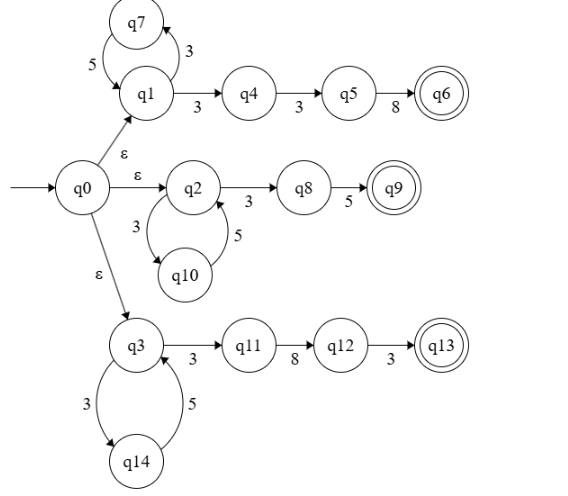

In [ ]:
display(Image('drive/MyDrive/files/Ejercicio4.png'))

**Implementación del autómata con automata-lib**:

In [ ]:
def punto4():
    from automata.fa.nfa import NFA

    d = NFA(
        states ={'q0','q1','q2','q3','q4','q5','q6','q7','q8','q9','q10','q11','q12','q13','q14'},
        input_symbols={'8','3','5'},
        transitions={
            'q0':{'':{'q1','q2','q3'}},
            'q1':{'3':{'q4','q7'}},
            'q2':{'3':{'q8','q10'}},
            'q3':{'3':{'q11','q14'}},
            'q4':{'3':{'q5'}},
            'q5':{'8':{'q6'}},
            'q6':{},
            'q7':{'5':{'q1'}},
            'q8':{'5':{'q9'}},
            'q9':{},
            'q10':{'5':{'q2'}},
            'q11':{'8':{'q12'}},
            'q12':{'3':{'q13'}},
            'q13':{},
            'q14':{'5':{'q3'}},
          },
        initial_state='q0',
        final_states={'q6','q9','q13'},
    )
    return d


#### Evalue su respuesta antes de subirla:

In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_4():
    d = punto4()
    valid_words = ['35338',
                   '353535',
                   '35383',
                   '338',
                   '35']

    invalid_words = ['35883',
                     '35558',
                     '35333',
                     '355',
                     '358']

    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_4():
  print('MUY BIEN! El diseño es correcto')
else:
  print('MAL! El diseño es incorrecto. Sigue intentando')

MUY BIEN! El diseño es correcto


<div style="height:100px;"></div>

**5)** Diseñe un NFA sobre el alfabeto $\Sigma = \{i,j,k\}$ para el lenguaje:<br><br>
$$L = \{\enspace i \ k^{+} \ (j + k)^{+} \enspace \cup \enspace i \ k \ (ij)^{*} \enspace \}$$

**NOTA** Dibuje el diagrama de transiciones e implemente el autómata con automata-lib.

**Diagrama de transiciones:**

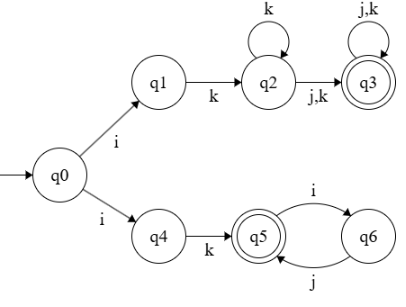

In [ ]:
display(Image('drive/MyDrive/files/Ejercicio5 |.png'))

**Implementación del autómata con automata-lib**:

In [ ]:
def punto5():
    from automata.fa.nfa import NFA

    d = NFA(
    states={'q0','q1','q2','q3','q4','q5','q6'},
    input_symbols={'i','j','k'},
    transitions={
        'q0':{'i':{'q1','q4'}},
        'q1':{'k':{'q2'}},
        'q2':{'k':{'q2','q3'},"j":{'q3'}},
        'q3':{'j':{'q3'},'k':{'q3'}},
        'q4':{'k':{'q5'}},
        'q5':{'i':{'q6'}},
        'q6':{'j':{'q5'}},

    },
    initial_state='q0',
    final_states={'q3','q5'},
    )
    return d

#### Evalue su respuesta antes de subirla:

In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_5():
    d = punto5()
    valid_words = ['ik',
                   'ikijij',
                   'ikj',
                   'ikk',
                   'ikkjk']

    invalid_words = ['iki',
                     'ikiji',
                     'ikii',
                     'ikji',
                     'ikiij']

    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_5():
  print('MUY BIEN! El diseño es correcto')
else:
  print('MAL! El diseño es incorrecto. Sigue intentando')

MUY BIEN! El diseño es correcto


<div style="height:100px;"></div>

**6)** De acuerdo con el siguiente **AFN-$\varepsilon$**:

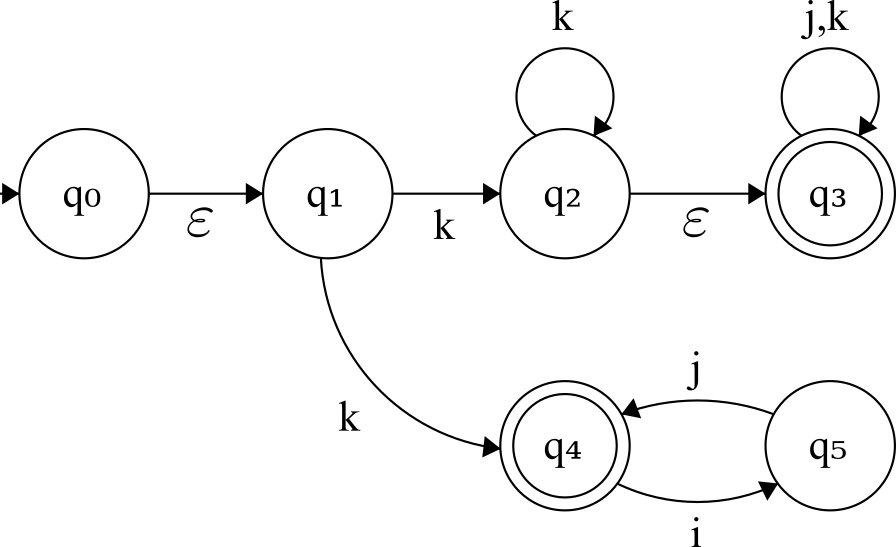

In [ ]:
display(Image('files/t01_06.png'))

En este punto deberá elaborar:

**a) Tabla del AFD correspondiente**

<table style="border-collapse:collapse; border:1px solid black; width:400px;">

<tr>
<td style="text-align:center;width:80px;"></td>
<td style="text-align:center;width:120px;">$i$</td>
<td style="text-align:center;width:120px;">$j$</td>
<td style="text-align:center;width:120px;">$k$</td>
</tr>

<tr>
<td style="text-align:center;">$\rightarrow ?$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
</tr>

<tr>
<td style="text-align:center;">$* ?$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
</tr>

<tr>
<td style="text-align:center;">$* ?$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
</tr>

<tr>
<td style="text-align:center;">$* ?$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
</tr>

<tr>
<td style="text-align:center;">$* ?$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
</tr>

<tr>
<td style="text-align:center;">$?$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
<td style="text-align:center;">$\oslash$</td>
</tr>

</table>
<br>
<center><div>Tabla 2. Tabla del AFD correspondiente</div></center>

**b) Diagrama de transiciones del **AFD** <span style="text-decoration:underline;">equivalente</span>**

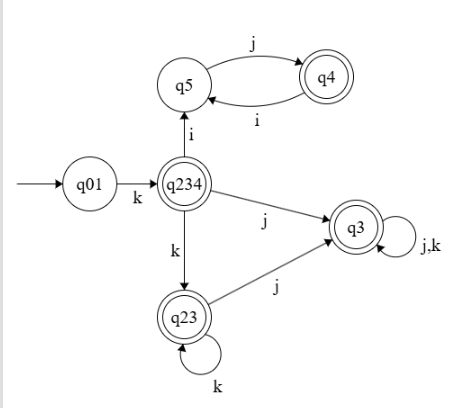

In [ ]:
display(Image('drive/MyDrive/files/Ejercicio6.png'))

<br><br>
**c) Implementación del AFD con automata-lib**:

In [ ]:
def punto6b():
    from automata.fa.dfa import DFA

    d = DFA(
    states={'q01','q234','q5','q3','q23','q4'},
    input_symbols={'i','j','k'},
    transitions={
        'q01':{'k':'q234'},
        'q234':{'i':'q5','j':'q3','k':'q3'},
        'q5':{'j':'q4'},
        'q3':{'j':'q3','k':'q3'},
        'q23':{'j':'q3','k':'q23'},
        'q4':{'i':'q5'},
    },
    initial_state='q01',
    final_states={'q234','q3','q23','q4'},
    allow_partial = True
    )
    return d

#### Evalue su respuesta antes de subirla:

In [ ]:
###########################
# NO MODIFICAR ESTA CELDA #
###########################

def grade_6b():
    d = punto6b()
    valid_words = ['k',
                   'kj',
                   'kk',
                   'kkj',
                   'kij']

    invalid_words = ['kii',
                     'kijj',
                     'kijk',
                     'kki',
                     'kji']

    for i in valid_words:
        if d.accepts_input(i) != True:
            return False
    for j in invalid_words:
        if d.accepts_input(j) != False:
            return False
    return True

if grade_6b():
  print('MUY BIEN! El diseño es correcto')
else:
  print('MAL! El diseño es incorrecto. Sigue intentando')

MUY BIEN! El diseño es correcto


<div style="height:100px;"></div>

<p style="font-size:20px;font-weight:bold;"><span style="background-color:#F00;color:#FFF;padding:10px;">Obligatorio</span></p>
<p style="font-size:20px;font-weight:bold;">Por favor, descargue el notebook en formato .ipynb y colóquele como nombre su código de estudiante antes de subirlo a la plataforma Moodle.</p>